Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Processing FAO Dataset...
 Loaded 11926 rows and 7 columns from /content/drive/My Drive/FarmWise/Cleaned_Data/FAO/Selected.csv
 Feature Selection Done! Saved as: /content/drive/My Drive/FarmWise/Cleaned_Data/FAO/Selected.csv


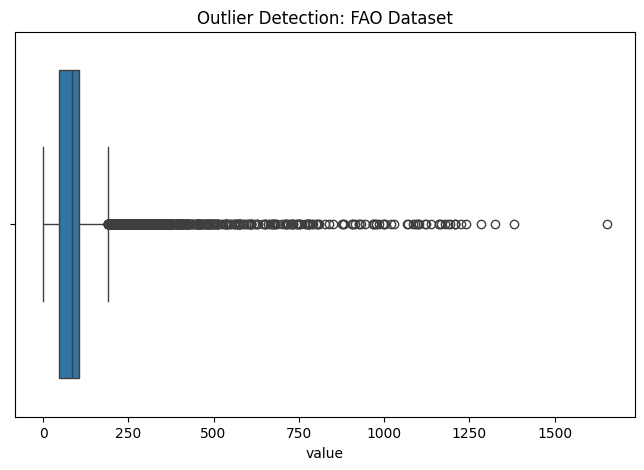


🔍 Outliers Found in FAO: 225
       year     area                 item   value   z_score
878    1990  Tunisia           Beans, dry  420.20  3.165972
879    1991  Tunisia           Beans, dry  674.27  5.645923
880    1992  Tunisia           Beans, dry  732.90  6.218205
881    1993  Tunisia           Beans, dry  879.48  7.648957
914    1990  Tunisia           Beans, dry  578.35  4.709658
...     ...      ...                  ...     ...       ...
11779  1992  Tunisia  Sugar Crops Primary  496.31  3.908874
11780  1993  Tunisia  Sugar Crops Primary  411.32  3.079295
11782  1995  Tunisia  Sugar Crops Primary  436.80  3.328003
11783  1996  Tunisia  Sugar Crops Primary  487.15  3.819464
11784  1997  Tunisia  Sugar Crops Primary  421.60  3.179637

[225 rows x 5 columns]
 Outlier Handling Done! Saved as: /content/drive/My Drive/FarmWise/Cleaned_Data/FAO/Cleaned.csv


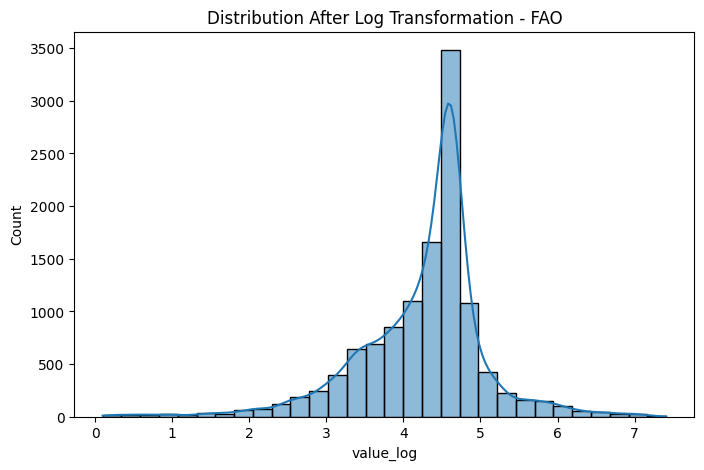


 Processing SoilGrids250m Dataset...
 Loaded 739643 rows and 4 columns from /content/drive/My Drive/FarmWise/Cleaned_Data/SoilGrids250m/Cleaned.csv
 Feature Selection Done! Saved as: /content/drive/My Drive/FarmWise/Cleaned_Data/SoilGrids250m/Selected.csv


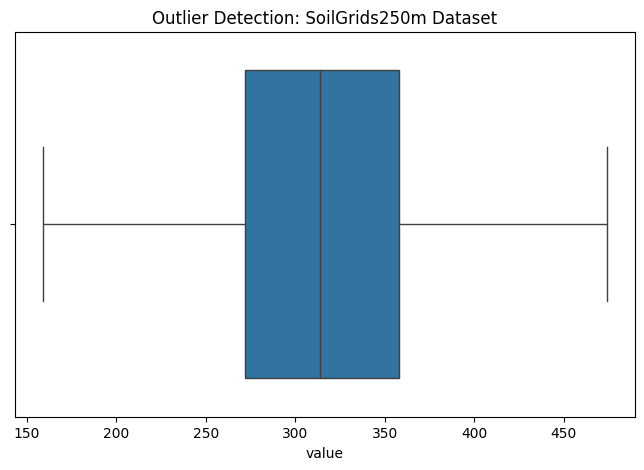


🔍 Outliers Found in SoilGrids250m: 0
Empty DataFrame
Columns: [value, z_score]
Index: []
 Outlier Handling Done! Saved as: /content/drive/My Drive/FarmWise/Cleaned_Data/SoilGrids250m/Cleaned.csv


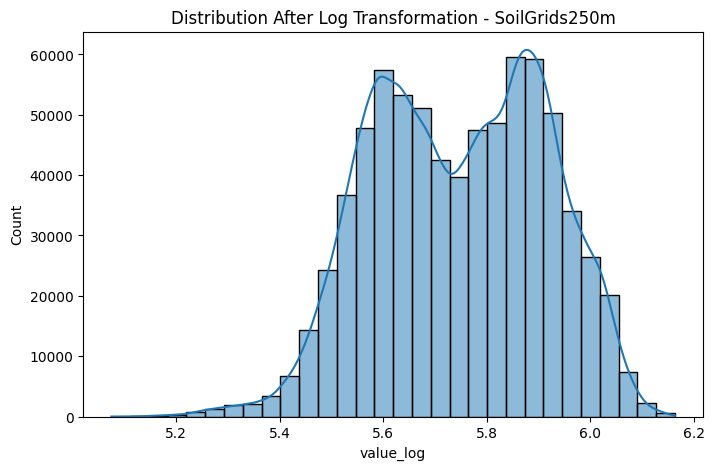


 Processing Agridata Dataset...
 Loaded 790 rows and 3 columns from /content/drive/My Drive/FarmWise/Cleaned_Data/agridata/Selected.csv
 Feature Selection Done! Saved as: /content/drive/My Drive/FarmWise/Cleaned_Data/agridata/Selected.csv

 Feature Selection & Outlier Handling Completed for All Datasets!


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import drive


drive.mount('/content/drive')


DATA_PATHS = {
    "FAO": "/content/drive/My Drive/FarmWise/Cleaned_Data/FAO/",
    "SoilGrids250m": "/content/drive/My Drive/FarmWise/Cleaned_Data/SoilGrids250m/",
    "Agridata": "/content/drive/My Drive/FarmWise/Cleaned_Data/agridata/"
}


def find_first_csv(folder_path):
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".csv"):
                return os.path.join(root, file)
    return None


def process_dataset(dataset_name, folder_path):
    print(f"\n Processing {dataset_name} Dataset...")
    file_path = find_first_csv(folder_path)

    if not file_path:
        print(f" No CSV files found in {dataset_name}!")
        return

    df = pd.read_csv(file_path)

    if df.empty:
        print(f" Warning: {dataset_name} dataset is empty!")
        return

    print(f" Loaded {df.shape[0]} rows and {df.shape[1]} columns from {file_path}")


    drop_columns = [col for col in ["domain_code", "domain", "element_code", "area_code_m49", "flag", "flag_description"] if col in df.columns]
    df_selected = df.drop(columns=drop_columns, errors='ignore')


    selected_file_path = os.path.join(folder_path, "Selected.csv")
    df_selected.to_csv(selected_file_path, index=False)
    print(f" Feature Selection Done! Saved as: {selected_file_path}")


    numeric_cols = df_selected.select_dtypes(include=np.number).columns.tolist()

    if "value" in numeric_cols:
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=df_selected['value'])
        plt.title(f"Outlier Detection: {dataset_name} Dataset")
        plt.show()


        z_scores = stats.zscore(df_selected['value'])
        df_selected['z_score'] = z_scores
        outliers = df_selected[df_selected['z_score'].abs() > 3]

        print(f"\n🔍 Outliers Found in {dataset_name}: {len(outliers)}")


        existing_cols = [col for col in ['year', 'area', 'item', 'value', 'z_score'] if col in df_selected.columns]
        print(outliers[existing_cols])


        df_cleaned = df_selected[df_selected['z_score'].abs() <= 3]
        cleaned_file_path = os.path.join(folder_path, "Cleaned.csv")
        df_cleaned.to_csv(cleaned_file_path, index=False)
        print(f" Outlier Handling Done! Saved as: {cleaned_file_path}")


        df_selected['value_log'] = np.log1p(df_selected['value'])
        plt.figure(figsize=(8, 5))
        sns.histplot(df_selected['value_log'], bins=30, kde=True)
        plt.title(f"Distribution After Log Transformation - {dataset_name}")
        plt.show()


for dataset_name, folder_path in DATA_PATHS.items():
    process_dataset(dataset_name, folder_path)

print("\n Feature Selection & Outlier Handling Completed for All Datasets!")
